## Final model building

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:

df_params = pd.read_csv("../Data/CSVs/best_model_parameters.csv", index_col=0)


In [3]:


gbr_params = df_params.loc["GBR"].dropna().to_dict()


In [4]:
int_params = ['max_depth', 'n_estimators', 'min_samples_leaf', 'min_samples_split', 'random_state', 'verbose']
for param in int_params:
    if param in gbr_params:
        gbr_params[param] = int(gbr_params[param])



In [5]:
gbr_params

{'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'random_state': 42,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False,
 'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'min_impurity_decrease': 0.0,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 300,
 'subsample': 1.0}

In [6]:

df_data = pd.read_csv("../Data/CSVs/Dopamine_D2_receptor_04_bioactivity_data_model.csv")


In [7]:

X = df_data.drop(columns=['pIC50'])
y = df_data['pIC50']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
selector = VarianceThreshold(threshold=0.1)
X_train_filtered = selector.fit_transform(X_train)
X_test_filtered = selector.transform(X_test)

In [10]:
print(f"Features reduced from {X_train.shape[1]} to {X_train_filtered.shape[1]}")

Features reduced from 1029 to 87


In [11]:
final_model = GradientBoostingRegressor(**gbr_params)
final_model.fit(X_train_filtered, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [12]:
y_pred = final_model.predict(X_test_filtered)

In [13]:
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [14]:
print(f"Test R-Squared : {final_r2:.4f}")
print(f"Test RMSE      : {final_rmse:.4f}\n")

Test R-Squared : 0.7475
Test RMSE      : 0.8050



In [15]:
model_filename = "../Final Model/final_evaluated_GBR_model.pkl"
selector_filename = "../Final Model/final_variance_selector.pkl"

joblib.dump(final_model, model_filename)
joblib.dump(selector, selector_filename)

print(f"Success! Files extracted and saved:")
print(f"1. {model_filename} (The Model)")
print(f"2. {selector_filename} (The Feature Filter)")

Success! Files extracted and saved:
1. ../Final Model/final_evaluated_GBR_model.pkl (The Model)
2. ../Final Model/final_variance_selector.pkl (The Feature Filter)


### Model visualizattion

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

C:\Users\HP\AppData\Local\Temp\ipykernel_3744\2343744461.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_features[1:], x='Importance', y='Feature', palette='viridis')


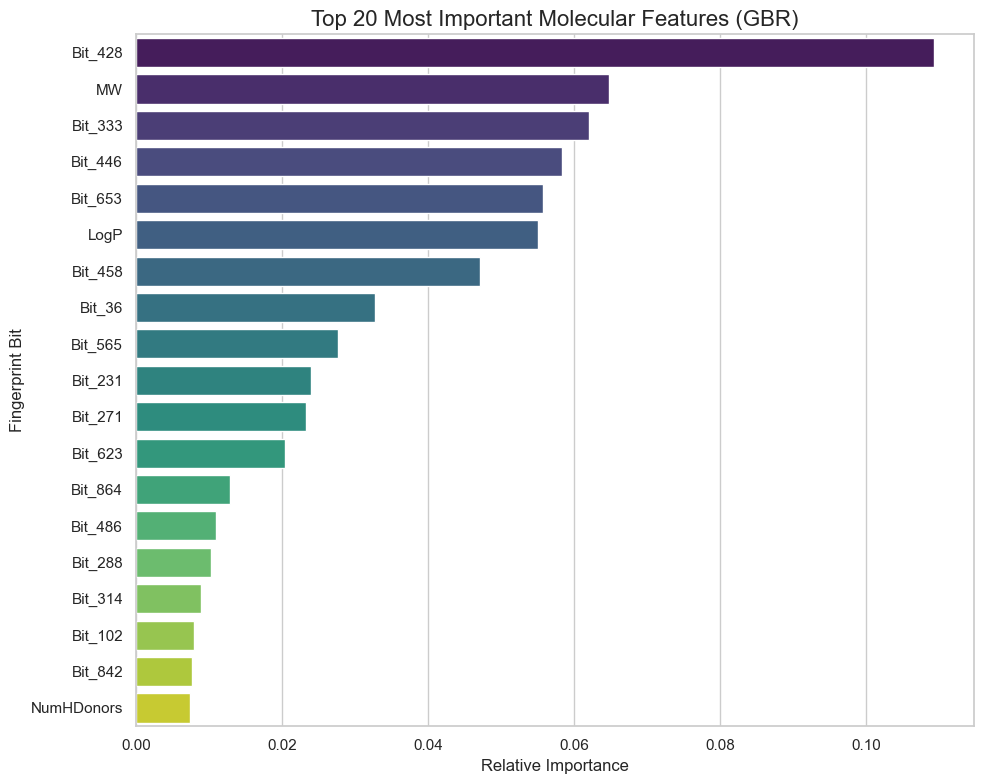

In [20]:
original_feature_names = X.columns

kept_feature_names = original_feature_names[selector.get_support()]


importance_df = pd.DataFrame({
    'Feature': kept_feature_names,
    'Importance': final_model.feature_importances_
})

top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_20_features[1:], x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Most Important Molecular Features (GBR)', fontsize=16)
plt.xlabel('Relative Importance')
plt.ylabel('Fingerprint Bit')
plt.tight_layout()
plt.show()

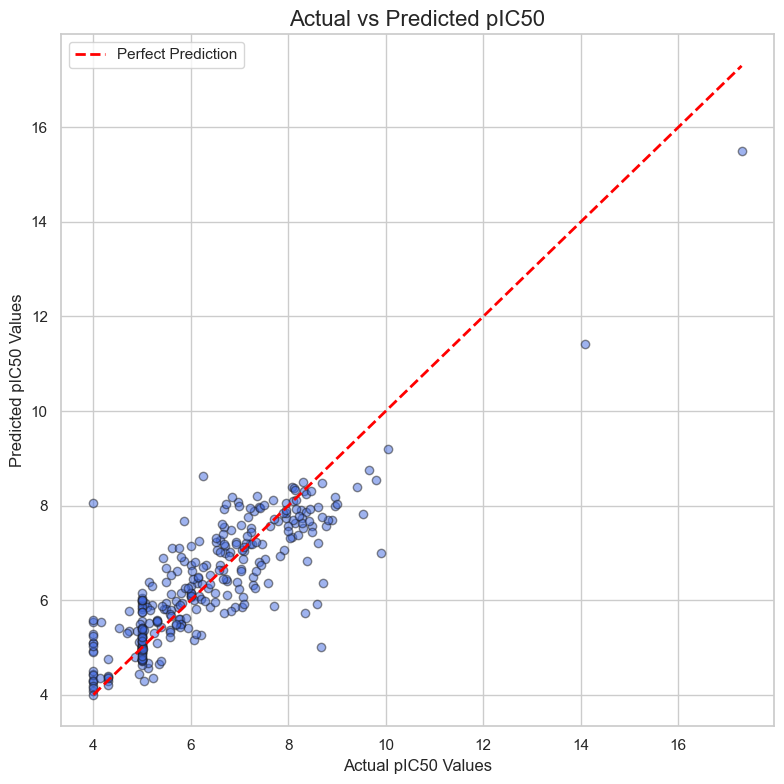

In [21]:
# Generate predictions for the test set
y_pred = final_model.predict(X_test_filtered)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', edgecolors='k')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted pIC50', fontsize=16)
plt.xlabel('Actual pIC50 Values', fontsize=12)
plt.ylabel('Predicted pIC50 Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

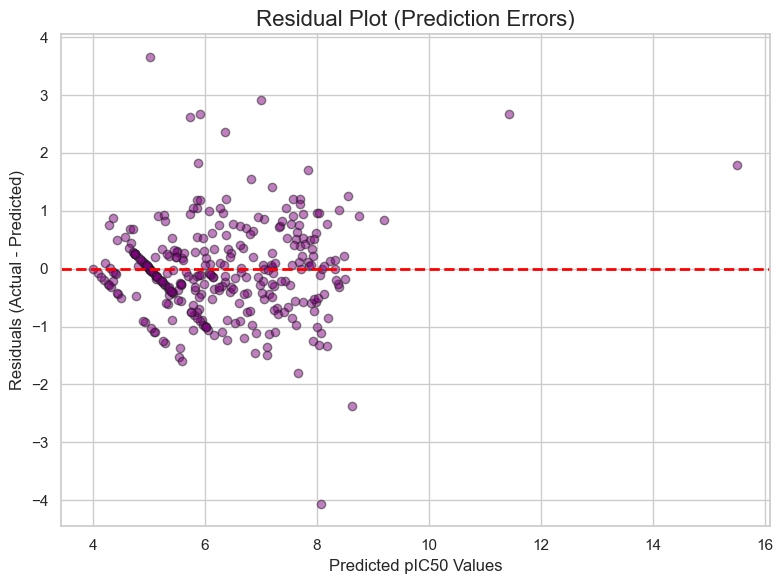

In [22]:
# Calculate residuals (Difference between actual and predicted)
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple', edgecolors='k')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Prediction Errors)', fontsize=16)
plt.xlabel('Predicted pIC50 Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.tight_layout()
plt.show()